<a href="https://colab.research.google.com/github/arundhatimsb/assignment/blob/main/VAE_remote_sensing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install torch torchvision matplotlib scikit-learn

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import transforms
from torchvision.datasets import EuroSAT
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
import numpy as np

In [3]:
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

dataset = EuroSAT(root="data", transform=transform, download=True)

dataset_size = len(dataset)
traindata_size = int(0.7 * dataset_size)
valdata_size = int(0.15 * dataset_size)
testdata_size = dataset_size - traindata_size - valdata_size


100%|██████████| 94.3M/94.3M [00:00<00:00, 103MB/s]


In [4]:


traindataset, valdataset, testdataset = random_split(
    dataset,
    [traindata_size, valdata_size, testdata_size]
)

train_loader = DataLoader(traindataset,
                          batch_size=64,
                          shuffle=True)
val_loader = DataLoader(valdataset,
                        batch_size=64,
                        shuffle=False)

test_loader = DataLoader(testdataset,
                         batch_size=64,
                         shuffle=False)

print("Total Images: ",dataset_size)
print("Training images:", len(traindataset))
print("Validation images:", len(valdataset))
print("Test images:", len(testdataset))
print("classes: ", dataset.classes)

Total Images:  27000
Training images: 18900
Validation images: 4050
Test images: 4050
classes:  ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


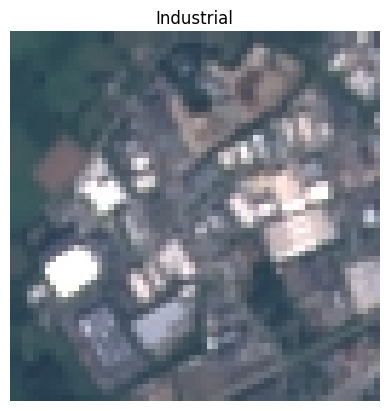

In [5]:
img, label = traindataset[0]
plt.imshow(img.permute(1,2,0))
plt.title(dataset.classes[label])
plt.axis("off");

In [6]:
class Encoder(nn.Module):
  def __init__(self, latent_dim = 32):
    super().__init__()
    self.conv = nn.Sequential(
        nn.Conv2d(3,32,4,2,1),
        nn.ReLU(),
        nn.Conv2d(32,64,4,2,1),
        nn.ReLU(),
        nn.Conv2d(64,128,4,2,1),
        nn.ReLU(),
        nn.Conv2d(128,256,4,2,1),
        nn.ReLU()
    )
    self.fc_mu = nn.Linear(4096, latent_dim)
    self.fc_logvar = nn.Linear(4096, latent_dim)

  def forward(self, x):
    x = self.conv(x)
    x = x.view(x.size(0),-1)
    mu = self.fc_mu(x)
    logvar = self.fc_logvar(x)
    z = self.reparameterize(mu, logvar)
    return z, mu, logvar

  def reparameterize(self,mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std



In [7]:
# @title
class Decoder(nn.Module):
  def __init__(self, latent_dim = 32):
    super().__init__()

    self.fc = nn.Linear(latent_dim, 4096)

    self.deconv = nn.Sequential(
      nn.ConvTranspose2d(256,128,4,2,1),
      nn.ReLU(),
      nn.ConvTranspose2d(128,64,4,2,1),
      nn.ReLU(),
      nn.ConvTranspose2d(64,32,4,2,1),
      nn.ReLU(),
      nn.ConvTranspose2d(32,3,4,2,1),
      nn.Sigmoid()
    )
  def forward(self,z):
    x = self.fc(z)
    x = x.view(-1, 256, 4, 4)
    x = self.deconv(x)
    return x

In [8]:
class VAE(nn.Module):

    def __init__(self, latent_dim=32):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self,x):
        z, mu, logvar = self.encoder.forward(x)
        recon = self.decoder(z)
        return recon, mu, logvar

In [9]:
def loss_function(recon_x, x, mu, logvar):

    recon_loss = F.mse_loss(recon_x,x,reduction='sum')

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return recon_loss + kl_loss

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 15
for epoch in range(epochs):
  total_loss = 0
  # print(epoch)
  for x,_ in train_loader:
    # print(x)
    # print(_)
    x = x.to(device)
    optimizer.zero_grad()
    recon, mu, logvar = model(x)
    loss = loss_function(recon,x,mu,logvar)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
  print("Epoch:",epoch+1,"Loss:",total_loss)

Epoch: 1 Loss: 2813130.8205566406
Epoch: 2 Loss: 1821364.3176269531


In [ ]:
z = torch.randn(16,32).to(device)

samples = model.decoder(z)

samples = samples.cpu().detach()

fig,ax = plt.subplots(4,4)

k=0

for i in range(4):
    for j in range(4):

        ax[i,j].imshow(samples[k].permute(1,2,0))
        ax[i,j].axis('off')
        k+=1

In [ ]:
z = torch.randn(16,32).to(device)

samples = model.decoder(z)

samples = samples.cpu().detach()

fig,ax = plt.subplots(4,4)

k=0

for i in range(4):
    for j in range(4):

        ax[i,j].imshow(samples[k].permute(1,2,0))
        ax[i,j].axis('off')
        k+=1

In [ ]:
forest_latents = []

for x,label in dataset:

    if label == dataset.class_to_idx['Forest']:

        x = x.unsqueeze(0).to(device)

        mu,_ = model.encoder(x)

        forest_latents.append(mu)

forest_vector = torch.mean(torch.cat(forest_latents),0)

In [ ]:
forest_latents = []

for x,label in dataset:

    if label == dataset.class_to_idx['Forest']:

        x = x.unsqueeze(0).to(device)

        mu,_ = model.encoder(x)

        forest_latents.append(mu)

forest_vector = torch.mean(torch.cat(forest_latents),0)

In [ ]:
paving_vector = highway_vector - forest_vector
river_img,_ = dataset[50]

river_img = river_img.unsqueeze(0).to(device)

mu,_ = model.encoder(river_img)

new_z = mu + paving_vector

result = model.decoder(new_z)

In [ ]:
plt.imshow(result.squeeze().permute(1,2,0).cpu().detach())
plt.axis('off')